In [ ]:
import re
import pandas as pd


# Read the input file
with open('results/DE_demand_increase_sensitivity/Balance Model/10 trial inc demand/two_phase_UG_828588.txt', 'r') as file:
    content = file.read()

# Define patterns to extract specific values
patterns = {
    'trial': r'^trial: (\d+)$',
    'explored': r'^Explored (\d+) nodes \((\d+) simplex iterations\) in ([\d.]+) seconds \(([\d.]+) work units\)$',
    'best_obj': r'^Best objective ([\d.e+]+), best bound ([\d.e+]+), gap ([\d.]+)%$',
    'status': r'^DE Model status: (OPTIMAL)$',
    'obj_value': r'^Objective Value: ([\d.e+]+)$',
    'mvp_model': r'^MVP Model$',
    'manual_calc': r'^Manual calculation of the objective value function:$',
    'f_obj': r'^F Objective value: ([\d.e+]+)$',
    'q_obj': r'^Q Objective value: ([\d.e+]+)$',
    's_obj': r'^S Objective value: ([\d.e+]+)$',
    'i_obj': r'^I Objective value: ([\d.e+]+)$',
    'y_obj': r'^Y Objective value: ([\d.e+]+)$',
    'l_obj': r'^L Objective value: ([\d.e+]+)$',
    'total_obj': r'^Total Objective value: ([\d.e+]+)$'
}

# Split content into trials
trials = content.split('trial: ')[1:]  # Skip empty split before first trial
table_data = []

for trial in trials:
    trial_lines = trial.strip().split('\n')
    trial_data = {
        'Trial': None, 'Explored Nodes': None, 'Simplex Iterations': None,
        'Time (s)': None, 'Work Units': None, 'Best Objective': None,
        'Best Bound': None, 'Gap (%)': None, 'DE Model Status': None,
        'Objective Value': None, 'F Objective': None, 'Q Objective': None,
        'S Objective': None, 'I Objective': None, 'Total Objective': None
    }
    
    for line in trial_lines:
        line = line.strip()
        for key, pattern in patterns.items():
            match = re.match(pattern, line)
            if match:
                if key == 'trial':
                    trial_data['Trial'] = int(match.group(1))
                elif key == 'explored':
                    trial_data['Explored Nodes'] = int(match.group(1))
                    trial_data['Simplex Iterations'] = int(match.group(2))
                    trial_data['Time (s)'] = float(match.group(3))
                    trial_data['Work Units'] = float(match.group(4))
                elif key == 'best_obj':
                    trial_data['Best Objective'] = float(match.group(1))
                    trial_data['Best Bound'] = float(match.group(2))
                    trial_data['Gap (%)'] = float(match.group(3))
                elif key == 'status':
                    trial_data['DE Model Status'] = match.group(1)
                elif key == 'obj_value':
                    trial_data['Objective Value'] = float(match.group(1))
                elif key == 'f_obj':
                    trial_data['F Objective'] = float(match.group(1))
                elif key == 'q_obj':
                    trial_data['Q Objective'] = float(match.group(1))
                elif key == 's_obj':
                    trial_data['S Objective'] = float(match.group(1))
                elif key == 'i_obj':
                    trial_data['I Objective'] = float(match.group(1))
                elif key == 'y_obj':
                    trial_data['Y Objective'] = float(match.group(1))
                elif key == 'l_obj':
                    trial_data['L Objective'] = float(match.group(1))
                elif key == 'total_obj':
                    trial_data['Total Objective'] = float(match.group(1))
    
    table_data.append(trial_data)

# Create DataFrame
df = pd.DataFrame(table_data, columns=[
    'Trial', 'Explored Nodes', 'Simplex Iterations', 'Time (s)', 'Work Units',
    'Best Objective', 'Best Bound', 'Gap (%)', 'DE Model Status', 'Objective Value',
    'F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective'
])

# Export to Excel
# df.to_excel('MP_parsed_trials_table_demand_increase.xlsx', index=False, engine='openpyxl')

# Print DataFrame to console
# print(df)

# Columns to include in the dictionary
columns = ['F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective']

# Format numbers to match the example's scientific notation (e.g., 2.65E+09)
def format_scientific(x):
    return f"{x:.2E}"  # Format with 2 decimal places for the coefficient

# Create dictionary
result_dict = {col: [f"{float(val):.2E}" for val in df[col]] for col in columns}

# Format the dictionary as a string
dict_str = "data = {\n"
for key, values in result_dict.items():
    dict_str += f"    '{key}': [{', '.join(values)}],\n"
dict_str1 = dict_str.rstrip(',\n') + "\n}"

# # Write to file
# with open('formatted_objectives_dict.py', 'w') as file:
#     file.write(dict_str)

# Print to console
print(dict_str1)

In [ ]:
import re
import pandas as pd

# Read the input file
with open('results/DE_demand_increase_sensitivity/Balance Model/10 trial inc demand 3 segments/two_phase_UG_826748.txt', 'r') as file:
    content = file.read()

# Define patterns to extract specific values
patterns = {
    'trial': r'^trial: (\d+)$',
    'explored': r'^Explored (\d+) nodes \((\d+) simplex iterations\) in ([\d.]+) seconds \(([\d.]+) work units\)$',
    'best_obj': r'^Best objective ([\d.e+]+), best bound ([\d.e+]+), gap ([\d.]+)%$',
    'status': r'^DE Model status: (OPTIMAL)$',
    'obj_value': r'^Objective Value: ([\d.e+]+)$',
    'mvp_model': r'^MVP Model$',
    'manual_calc': r'^Manual calculation of the objective value function:$',
    'f_obj': r'^F Objective value: ([\d.e+]+)$',
    'q_obj': r'^Q Objective value: ([\d.e+]+)$',
    's_obj': r'^S Objective value: ([\d.e+]+)$',
    'i_obj': r'^I Objective value: ([\d.e+]+)$',
    'y_obj': r'^Y Objective value: ([\d.e+]+)$',
    'l_obj': r'^L Objective value: ([\d.e+]+)$',
    'total_obj': r'^Total Objective value: ([\d.e+]+)$'
}

# Split content into trials
trials = content.split('trial: ')[1:]  # Skip empty split before first trial
table_data = []

for trial in trials:
    trial_lines = trial.strip().split('\n')
    trial_data = {
        'Trial': None, 'Explored Nodes': None, 'Simplex Iterations': None,
        'Time (s)': None, 'Work Units': None, 'Best Objective': None,
        'Best Bound': None, 'Gap (%)': None, 'DE Model Status': None,
        'Objective Value': None, 'F Objective': None, 'Q Objective': None,
        'S Objective': None, 'I Objective': None, 'Total Objective': None
    }
    
    for line in trial_lines:
        line = line.strip()
        for key, pattern in patterns.items():
            match = re.match(pattern, line)
            if match:
                if key == 'trial':
                    trial_data['Trial'] = int(match.group(1))
                elif key == 'explored':
                    trial_data['Explored Nodes'] = int(match.group(1))
                    trial_data['Simplex Iterations'] = int(match.group(2))
                    trial_data['Time (s)'] = float(match.group(3))
                    trial_data['Work Units'] = float(match.group(4))
                elif key == 'best_obj':
                    trial_data['Best Objective'] = float(match.group(1))
                    trial_data['Best Bound'] = float(match.group(2))
                    trial_data['Gap (%)'] = float(match.group(3))
                elif key == 'status':
                    trial_data['DE Model Status'] = match.group(1)
                elif key == 'obj_value':
                    trial_data['Objective Value'] = float(match.group(1))
                elif key == 'f_obj':
                    trial_data['F Objective'] = float(match.group(1))
                elif key == 'q_obj':
                    trial_data['Q Objective'] = float(match.group(1))
                elif key == 's_obj':
                    trial_data['S Objective'] = float(match.group(1))
                elif key == 'i_obj':
                    trial_data['I Objective'] = float(match.group(1))
                elif key == 'y_obj':
                    trial_data['Y Objective'] = float(match.group(1))
                elif key == 'l_obj':
                    trial_data['L Objective'] = float(match.group(1))
                elif key == 'total_obj':
                    trial_data['Total Objective'] = float(match.group(1))
    
    table_data.append(trial_data)

# Create DataFrame
df = pd.DataFrame(table_data, columns=[
    'Trial', 'Explored Nodes', 'Simplex Iterations', 'Time (s)', 'Work Units',
    'Best Objective', 'Best Bound', 'Gap (%)', 'DE Model Status', 'Objective Value',
    'F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective'
])

# Export to Excel
# df.to_excel('MP_parsed_trials_table_demand_increase.xlsx', index=False, engine='openpyxl')

# Print DataFrame to console
# print(df)

# Columns to include in the dictionary
columns = ['F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective']

# Format numbers to match the example's scientific notation (e.g., 2.65E+09)
def format_scientific(x):
    return f"{x:.2E}"  # Format with 2 decimal places for the coefficient

# Create dictionary
result_dict = {col: [f"{float(val):.2E}" for val in df[col]] for col in columns}

# Format the dictionary as a string
dict_str = "data = {\n"
for key, values in result_dict.items():
    dict_str += f"    '{key}': [{', '.join(values)}],\n"
dict_str2 = dict_str.rstrip(',\n') + "\n}"

# # Write to file
# with open('formatted_objectives_dict.py', 'w') as file:
#     file.write(dict_str)

# Print to console
print(dict_str2)

In [ ]:
import re
import pandas as pd

# Read the input file
with open('results/DE_demand_increase_sensitivity/Balance Model/10 trial inc demand 3 segments no ROI/two_phase_UG_829302.txt', 'r') as file:
    content = file.read()

# Define patterns to extract specific values
patterns = {
    'trial': r'^trial: (\d+)$',
    'explored': r'^Explored (\d+) nodes \((\d+) simplex iterations\) in ([\d.]+) seconds \(([\d.]+) work units\)$',
    'best_obj': r'^Best objective ([\d.e+]+), best bound ([\d.e+]+), gap ([\d.]+)%$',
    'status': r'^DE Model status: (OPTIMAL)$',
    'obj_value': r'^Objective Value: ([\d.e+]+)$',
    'mvp_model': r'^MVP Model$',
    'manual_calc': r'^Manual calculation of the objective value function:$',
    'f_obj': r'^F Objective value: ([\d.e+]+)$',
    'q_obj': r'^Q Objective value: ([\d.e+]+)$',
    's_obj': r'^S Objective value: ([\d.e+]+)$',
    'i_obj': r'^I Objective value: ([\d.e+]+)$',
    'y_obj': r'^Y Objective value: ([\d.e+]+)$',
    'l_obj': r'^L Objective value: ([\d.e+]+)$',
    'total_obj': r'^Total Objective value: ([\d.e+]+)$'
}

# Split content into trials
trials = content.split('trial: ')[1:]  # Skip empty split before first trial
table_data = []

for trial in trials:
    trial_lines = trial.strip().split('\n')
    trial_data = {
        'Trial': None, 'Explored Nodes': None, 'Simplex Iterations': None,
        'Time (s)': None, 'Work Units': None, 'Best Objective': None,
        'Best Bound': None, 'Gap (%)': None, 'DE Model Status': None,
        'Objective Value': None, 'F Objective': None, 'Q Objective': None,
        'S Objective': None, 'I Objective': None, 'Total Objective': None
    }
    
    for line in trial_lines:
        line = line.strip()
        for key, pattern in patterns.items():
            match = re.match(pattern, line)
            if match:
                if key == 'trial':
                    trial_data['Trial'] = int(match.group(1))
                elif key == 'explored':
                    trial_data['Explored Nodes'] = int(match.group(1))
                    trial_data['Simplex Iterations'] = int(match.group(2))
                    trial_data['Time (s)'] = float(match.group(3))
                    trial_data['Work Units'] = float(match.group(4))
                elif key == 'best_obj':
                    trial_data['Best Objective'] = float(match.group(1))
                    trial_data['Best Bound'] = float(match.group(2))
                    trial_data['Gap (%)'] = float(match.group(3))
                elif key == 'status':
                    trial_data['DE Model Status'] = match.group(1)
                elif key == 'obj_value':
                    trial_data['Objective Value'] = float(match.group(1))
                elif key == 'f_obj':
                    trial_data['F Objective'] = float(match.group(1))
                elif key == 'q_obj':
                    trial_data['Q Objective'] = float(match.group(1))
                elif key == 's_obj':
                    trial_data['S Objective'] = float(match.group(1))
                elif key == 'i_obj':
                    trial_data['I Objective'] = float(match.group(1))
                elif key == 'y_obj':
                    trial_data['Y Objective'] = float(match.group(1))
                elif key == 'l_obj':
                    trial_data['L Objective'] = float(match.group(1))
                elif key == 'total_obj':
                    trial_data['Total Objective'] = float(match.group(1))
    
    table_data.append(trial_data)

# Create DataFrame
df = pd.DataFrame(table_data, columns=[
    'Trial', 'Explored Nodes', 'Simplex Iterations', 'Time (s)', 'Work Units',
    'Best Objective', 'Best Bound', 'Gap (%)', 'DE Model Status', 'Objective Value',
    'F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective'
])

# Export to Excel
# df.to_excel('MP_parsed_trials_table_demand_increase.xlsx', index=False, engine='openpyxl')

# Print DataFrame to console
# print(df)

# Columns to include in the dictionary
columns = ['F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective']

# Format numbers to match the example's scientific notation (e.g., 2.65E+09)
def format_scientific(x):
    return f"{x:.2E}"  # Format with 2 decimal places for the coefficient

# Create dictionary
result_dict = {col: [f"{float(val):.2E}" for val in df[col]] for col in columns}

# Format the dictionary as a string
dict_str = "data = {\n"
for key, values in result_dict.items():
    dict_str += f"    '{key}': [{', '.join(values)}],\n"
dict_str10 = dict_str.rstrip(',\n') + "\n}"

# # Write to file
# with open('formatted_objectives_dict.py', 'w') as file:
#     file.write(dict_str)

# Print to console
print(dict_str10)

In [ ]:
import re
import pandas as pd

# Read the input file
with open('results/DE_demand_increase_sensitivity/SB Model/10 trial inc demand/two_phase_UG_827631.txt', 'r') as file:
    content = file.read()

# Define patterns to extract specific values
patterns = {
    'trial': r'^trial: (\d+)$',
    'explored': r'^Explored (\d+) nodes \((\d+) simplex iterations\) in ([\d.]+) seconds \(([\d.]+) work units\)$',
    'best_obj': r'^Best objective ([\d.e+]+), best bound ([\d.e+]+), gap ([\d.]+)%$',
    'status': r'^DE Model status: (OPTIMAL)$',
    'obj_value': r'^Objective Value: ([\d.e+]+)$',
    'mvp_model': r'^MVP Model$',
    'manual_calc': r'^Manual calculation of the objective value function:$',
    'f_obj': r'^F Objective value: ([\d.e+]+)$',
    'q_obj': r'^Q Objective value: ([\d.e+]+)$',
    's_obj': r'^S Objective value: ([\d.e+]+)$',
    'i_obj': r'^I Objective value: ([\d.e+]+)$',
    'y_obj': r'^Y Objective value: ([\d.e+]+)$',
    'l_obj': r'^L Objective value: ([\d.e+]+)$',
    'total_obj': r'^Total Objective value: ([\d.e+]+)$'
}

# Split content into trials
trials = content.split('trial: ')[1:]  # Skip empty split before first trial
table_data = []

for trial in trials:
    trial_lines = trial.strip().split('\n')
    trial_data = {
        'Trial': None, 'Explored Nodes': None, 'Simplex Iterations': None,
        'Time (s)': None, 'Work Units': None, 'Best Objective': None,
        'Best Bound': None, 'Gap (%)': None, 'DE Model Status': None,
        'Objective Value': None, 'F Objective': None, 'Q Objective': None,
        'S Objective': None, 'I Objective': None, 'Total Objective': None
    }
    
    for line in trial_lines:
        line = line.strip()
        for key, pattern in patterns.items():
            match = re.match(pattern, line)
            if match:
                if key == 'trial':
                    trial_data['Trial'] = int(match.group(1))
                elif key == 'explored':
                    trial_data['Explored Nodes'] = int(match.group(1))
                    trial_data['Simplex Iterations'] = int(match.group(2))
                    trial_data['Time (s)'] = float(match.group(3))
                    trial_data['Work Units'] = float(match.group(4))
                elif key == 'best_obj':
                    trial_data['Best Objective'] = float(match.group(1))
                    trial_data['Best Bound'] = float(match.group(2))
                    trial_data['Gap (%)'] = float(match.group(3))
                elif key == 'status':
                    trial_data['DE Model Status'] = match.group(1)
                elif key == 'obj_value':
                    trial_data['Objective Value'] = float(match.group(1))
                elif key == 'f_obj':
                    trial_data['F Objective'] = float(match.group(1))
                elif key == 'q_obj':
                    trial_data['Q Objective'] = float(match.group(1))
                elif key == 's_obj':
                    trial_data['S Objective'] = float(match.group(1))
                elif key == 'i_obj':
                    trial_data['I Objective'] = float(match.group(1))
                elif key == 'y_obj':
                    trial_data['Y Objective'] = float(match.group(1))
                elif key == 'l_obj':
                    trial_data['L Objective'] = float(match.group(1))
                elif key == 'total_obj':
                    trial_data['Total Objective'] = float(match.group(1))
    
    table_data.append(trial_data)

# Create DataFrame
df = pd.DataFrame(table_data, columns=[
    'Trial', 'Explored Nodes', 'Simplex Iterations', 'Time (s)', 'Work Units',
    'Best Objective', 'Best Bound', 'Gap (%)', 'DE Model Status', 'Objective Value',
    'F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective'
])

# Export to Excel
# df.to_excel('MP_parsed_trials_table_demand_increase.xlsx', index=False, engine='openpyxl')

# Print DataFrame to console
# print(df)

# Columns to include in the dictionary
columns = ['F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective']

# Format numbers to match the example's scientific notation (e.g., 2.65E+09)
def format_scientific(x):
    return f"{x:.2E}"  # Format with 2 decimal places for the coefficient

# Create dictionary
result_dict = {col: [f"{float(val):.2E}" for val in df[col]] for col in columns}

# Format the dictionary as a string
dict_str = "data = {\n"
for key, values in result_dict.items():
    dict_str += f"    '{key}': [{', '.join(values)}],\n"
dict_str4 = dict_str.rstrip(',\n') + "\n}"

# # Write to file
# with open('formatted_objectives_dict.py', 'w') as file:
#     file.write(dict_str)

# Print to console
print(dict_str4)

In [ ]:
import re
import pandas as pd

# Read the input file
with open('results/DE_demand_increase_sensitivity/SB Model/10 trial inc demand 3 segments/two_phase_UG_827305.txt', 'r') as file:
    content = file.read()

# Define patterns to extract specific values
patterns = {
    'trial': r'^trial: (\d+)$',
    'explored': r'^Explored (\d+) nodes \((\d+) simplex iterations\) in ([\d.]+) seconds \(([\d.]+) work units\)$',
    'best_obj': r'^Best objective ([\d.e+]+), best bound ([\d.e+]+), gap ([\d.]+)%$',
    'status': r'^DE Model status: (OPTIMAL)$',
    'obj_value': r'^Objective Value: ([\d.e+]+)$',
    'mvp_model': r'^MVP Model$',
    'manual_calc': r'^Manual calculation of the objective value function:$',
    'f_obj': r'^F Objective value: ([\d.e+]+)$',
    'q_obj': r'^Q Objective value: ([\d.e+]+)$',
    's_obj': r'^S Objective value: ([\d.e+]+)$',
    'i_obj': r'^I Objective value: ([\d.e+]+)$',
    'y_obj': r'^Y Objective value: ([\d.e+]+)$',
    'l_obj': r'^L Objective value: ([\d.e+]+)$',
    'total_obj': r'^Total Objective value: ([\d.e+]+)$'
}

# Split content into trials
trials = content.split('trial: ')[1:]  # Skip empty split before first trial
table_data = []

for trial in trials:
    trial_lines = trial.strip().split('\n')
    trial_data = {
        'Trial': None, 'Explored Nodes': None, 'Simplex Iterations': None,
        'Time (s)': None, 'Work Units': None, 'Best Objective': None,
        'Best Bound': None, 'Gap (%)': None, 'DE Model Status': None,
        'Objective Value': None, 'F Objective': None, 'Q Objective': None,
        'S Objective': None, 'I Objective': None, 'Total Objective': None
    }
    
    for line in trial_lines:
        line = line.strip()
        for key, pattern in patterns.items():
            match = re.match(pattern, line)
            if match:
                if key == 'trial':
                    trial_data['Trial'] = int(match.group(1))
                elif key == 'explored':
                    trial_data['Explored Nodes'] = int(match.group(1))
                    trial_data['Simplex Iterations'] = int(match.group(2))
                    trial_data['Time (s)'] = float(match.group(3))
                    trial_data['Work Units'] = float(match.group(4))
                elif key == 'best_obj':
                    trial_data['Best Objective'] = float(match.group(1))
                    trial_data['Best Bound'] = float(match.group(2))
                    trial_data['Gap (%)'] = float(match.group(3))
                elif key == 'status':
                    trial_data['DE Model Status'] = match.group(1)
                elif key == 'obj_value':
                    trial_data['Objective Value'] = float(match.group(1))
                elif key == 'f_obj':
                    trial_data['F Objective'] = float(match.group(1))
                elif key == 'q_obj':
                    trial_data['Q Objective'] = float(match.group(1))
                elif key == 's_obj':
                    trial_data['S Objective'] = float(match.group(1))
                elif key == 'i_obj':
                    trial_data['I Objective'] = float(match.group(1))
                elif key == 'y_obj':
                    trial_data['Y Objective'] = float(match.group(1))
                elif key == 'l_obj':
                    trial_data['L Objective'] = float(match.group(1))
                elif key == 'total_obj':
                    trial_data['Total Objective'] = float(match.group(1))
    
    table_data.append(trial_data)

# Create DataFrame
df = pd.DataFrame(table_data, columns=[
    'Trial', 'Explored Nodes', 'Simplex Iterations', 'Time (s)', 'Work Units',
    'Best Objective', 'Best Bound', 'Gap (%)', 'DE Model Status', 'Objective Value',
    'F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective'
])

# Export to Excel
# df.to_excel('MP_parsed_trials_table_demand_increase.xlsx', index=False, engine='openpyxl')

# Print DataFrame to console
# print(df)

# Columns to include in the dictionary
columns = ['F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective']

# Format numbers to match the example's scientific notation (e.g., 2.65E+09)
def format_scientific(x):
    return f"{x:.2E}"  # Format with 2 decimal places for the coefficient

# Create dictionary
result_dict = {col: [f"{float(val):.2E}" for val in df[col]] for col in columns}

# Format the dictionary as a string
dict_str = "data = {\n"
for key, values in result_dict.items():
    dict_str += f"    '{key}': [{', '.join(values)}],\n"
dict_str5 = dict_str.rstrip(',\n') + "\n}"

# # Write to file
# with open('formatted_objectives_dict.py', 'w') as file:
#     file.write(dict_str)

# Print to console
print(dict_str5)

In [ ]:
import re
import pandas as pd

# Read the input file
with open('results/DE_demand_increase_sensitivity/SB Model/10 trial inc demand 3 segments no ROI/two_phase_UG_829303.txt', 'r') as file:
    content = file.read()

# Define patterns to extract specific values
patterns = {
    'trial': r'^trial: (\d+)$',
    'explored': r'^Explored (\d+) nodes \((\d+) simplex iterations\) in ([\d.]+) seconds \(([\d.]+) work units\)$',
    'best_obj': r'^Best objective ([\d.e+]+), best bound ([\d.e+]+), gap ([\d.]+)%$',
    'status': r'^DE Model status: (OPTIMAL)$',
    'obj_value': r'^Objective Value: ([\d.e+]+)$',
    'mvp_model': r'^MVP Model$',
    'manual_calc': r'^Manual calculation of the objective value function:$',
    'f_obj': r'^F Objective value: ([\d.e+]+)$',
    'q_obj': r'^Q Objective value: ([\d.e+]+)$',
    's_obj': r'^S Objective value: ([\d.e+]+)$',
    'i_obj': r'^I Objective value: ([\d.e+]+)$',
    'y_obj': r'^Y Objective value: ([\d.e+]+)$',
    'l_obj': r'^L Objective value: ([\d.e+]+)$',
    'total_obj': r'^Total Objective value: ([\d.e+]+)$'
}

# Split content into trials
trials = content.split('trial: ')[1:]  # Skip empty split before first trial
table_data = []

for trial in trials:
    trial_lines = trial.strip().split('\n')
    trial_data = {
        'Trial': None, 'Explored Nodes': None, 'Simplex Iterations': None,
        'Time (s)': None, 'Work Units': None, 'Best Objective': None,
        'Best Bound': None, 'Gap (%)': None, 'DE Model Status': None,
        'Objective Value': None, 'F Objective': None, 'Q Objective': None,
        'S Objective': None, 'I Objective': None, 'Total Objective': None
    }
    
    for line in trial_lines:
        line = line.strip()
        for key, pattern in patterns.items():
            match = re.match(pattern, line)
            if match:
                if key == 'trial':
                    trial_data['Trial'] = int(match.group(1))
                elif key == 'explored':
                    trial_data['Explored Nodes'] = int(match.group(1))
                    trial_data['Simplex Iterations'] = int(match.group(2))
                    trial_data['Time (s)'] = float(match.group(3))
                    trial_data['Work Units'] = float(match.group(4))
                elif key == 'best_obj':
                    trial_data['Best Objective'] = float(match.group(1))
                    trial_data['Best Bound'] = float(match.group(2))
                    trial_data['Gap (%)'] = float(match.group(3))
                elif key == 'status':
                    trial_data['DE Model Status'] = match.group(1)
                elif key == 'obj_value':
                    trial_data['Objective Value'] = float(match.group(1))
                elif key == 'f_obj':
                    trial_data['F Objective'] = float(match.group(1))
                elif key == 'q_obj':
                    trial_data['Q Objective'] = float(match.group(1))
                elif key == 's_obj':
                    trial_data['S Objective'] = float(match.group(1))
                elif key == 'i_obj':
                    trial_data['I Objective'] = float(match.group(1))
                elif key == 'y_obj':
                    trial_data['Y Objective'] = float(match.group(1))
                elif key == 'l_obj':
                    trial_data['L Objective'] = float(match.group(1))
                elif key == 'total_obj':
                    trial_data['Total Objective'] = float(match.group(1))
    
    table_data.append(trial_data)

# Create DataFrame
df = pd.DataFrame(table_data, columns=[
    'Trial', 'Explored Nodes', 'Simplex Iterations', 'Time (s)', 'Work Units',
    'Best Objective', 'Best Bound', 'Gap (%)', 'DE Model Status', 'Objective Value',
    'F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective'
])

# Export to Excel
# df.to_excel('MP_parsed_trials_table_demand_increase.xlsx', index=False, engine='openpyxl')

# Print DataFrame to console
# print(df)

# Columns to include in the dictionary
columns = ['F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective']

# Format numbers to match the example's scientific notation (e.g., 2.65E+09)
def format_scientific(x):
    return f"{x:.2E}"  # Format with 2 decimal places for the coefficient

# Create dictionary
result_dict = {col: [f"{float(val):.2E}" for val in df[col]] for col in columns}

# Format the dictionary as a string
dict_str = "data = {\n"
for key, values in result_dict.items():
    dict_str += f"    '{key}': [{', '.join(values)}],\n"
dict_str11 = dict_str.rstrip(',\n') + "\n}"

# # Write to file
# with open('formatted_objectives_dict.py', 'w') as file:
#     file.write(dict_str)

# Print to console
print(dict_str11)

In [ ]:
import re
import pandas as pd

# Read the input file
with open('results/DE_demand_increase_sensitivity/MP Model/10 trial inc demand/two_phase_UG_828423.txt', 'r') as file:
    content = file.read()

# Define patterns to extract specific values
patterns = {
    'trial': r'^trial: (\d+)$',
    'explored': r'^Explored (\d+) nodes \((\d+) simplex iterations\) in ([\d.]+) seconds \(([\d.]+) work units\)$',
    'best_obj': r'^Best objective ([\d.e+]+), best bound ([\d.e+]+), gap ([\d.]+)%$',
    'status': r'^DE Model status: (OPTIMAL)$',
    'obj_value': r'^Objective Value: ([\d.e+]+)$',
    'mvp_model': r'^MVP Model$',
    'manual_calc': r'^Manual calculation of the objective value function:$',
    'f_obj': r'^F Objective value: ([\d.e+]+)$',
    'q_obj': r'^Q Objective value: (-?[\d.]+[eE][+-]?\d+)$',
    's_obj': r'^S Objective value: ([\d.e+]+)$',
    'i_obj': r'^I Objective value: ([\d.e+]+)$',
    'y_obj': r'^Y Objective value: ([\d.e+]+)$',
    'l_obj': r'^L Objective value: ([\d.e+]+)$',
    'total_obj': r'^Total Objective value: (-?[\d.e+]+)$'
}

# Split content into trials
trials = content.split('trial: ')[1:]  # Skip empty split before first trial
table_data = []

for trial in trials:
    trial_lines = trial.strip().split('\n')
    trial_data = {
        'Trial': None, 'Explored Nodes': None, 'Simplex Iterations': None,
        'Time (s)': None, 'Work Units': None, 'Best Objective': None,
        'Best Bound': None, 'Gap (%)': None, 'DE Model Status': None,
        'Objective Value': None, 'F Objective': None, 'Q Objective': None,
        'S Objective': None, 'I Objective': None, 'Total Objective': None
    }
    
    for line in trial_lines:
        line = line.strip()
        for key, pattern in patterns.items():
            match = re.match(pattern, line)
            if match:
                if key == 'trial':
                    trial_data['Trial'] = int(match.group(1))
                elif key == 'explored':
                    trial_data['Explored Nodes'] = int(match.group(1))
                    trial_data['Simplex Iterations'] = int(match.group(2))
                    trial_data['Time (s)'] = float(match.group(3))
                    trial_data['Work Units'] = float(match.group(4))
                elif key == 'best_obj':
                    trial_data['Best Objective'] = float(match.group(1))
                    trial_data['Best Bound'] = float(match.group(2))
                    trial_data['Gap (%)'] = float(match.group(3))
                elif key == 'status':
                    trial_data['DE Model Status'] = match.group(1)
                elif key == 'obj_value':
                    trial_data['Objective Value'] = float(match.group(1))
                elif key == 'f_obj':
                    trial_data['F Objective'] = float(match.group(1))
                elif key == 'q_obj':
                    trial_data['Q Objective'] = float(match.group(1))
                elif key == 's_obj':
                    trial_data['S Objective'] = float(match.group(1))
                elif key == 'i_obj':
                    trial_data['I Objective'] = float(match.group(1))
                elif key == 'y_obj':
                    trial_data['Y Objective'] = float(match.group(1))
                elif key == 'l_obj':
                    trial_data['L Objective'] = float(match.group(1))
                elif key == 'total_obj':
                    trial_data['Total Objective'] = float(match.group(1))
    
    table_data.append(trial_data)

# Create DataFrame
df = pd.DataFrame(table_data, columns=[
    'Trial', 'Explored Nodes', 'Simplex Iterations', 'Time (s)', 'Work Units',
    'Best Objective', 'Best Bound', 'Gap (%)', 'DE Model Status', 'Objective Value',
    'F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective'
])

# Export to Excel
# df.to_excel('MP_parsed_trials_table_demand_increase.xlsx', index=False, engine='openpyxl')

# Print DataFrame to console
# print(df)

# Columns to include in the dictionary
columns = ['F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective']

# Format numbers to match the example's scientific notation (e.g., 2.65E+09)
def format_scientific(x):
    return f"{x:.2E}"  # Format with 2 decimal places for the coefficient

# Create dictionary
result_dict = {col: [f"{float(val):.2E}" for val in df[col]] for col in columns}

# Format the dictionary as a string
dict_str = "data = {\n"
for key, values in result_dict.items():
    dict_str += f"    '{key}': [{', '.join(values)}],\n"
dict_str6 = dict_str.rstrip(',\n') + "\n}"

# # Write to file
# with open('formatted_objectives_dict.py', 'w') as file:
#     file.write(dict_str)

# Print to console
print(dict_str6)

In [ ]:
import re
import pandas as pd

# Read the input file
with open('results/DE_demand_increase_sensitivity/MP Model/10 trial inc demand 3 segments/two_phase_UG_826821.txt', 'r') as file:
    content = file.read()

# Define patterns to extract specific values
patterns = {
    'trial': r'^trial: (\d+)$',
    'explored': r'^Explored (\d+) nodes \((\d+) simplex iterations\) in ([\d.]+) seconds \(([\d.]+) work units\)$',
    'best_obj': r'^Best objective ([\d.e+]+), best bound ([\d.e+]+), gap ([\d.]+)%$',
    'status': r'^DE Model status: (OPTIMAL)$',
    'obj_value': r'^Objective Value: ([\d.e+]+)$',
    'mvp_model': r'^MVP Model$',
    'manual_calc': r'^Manual calculation of the objective value function:$',
    'f_obj': r'^F Objective value: ([\d.e+]+)$',
    'q_obj': r'^Q Objective value: (-?[\d.]+[eE][+-]?\d+)$',
    's_obj': r'^S Objective value: ([\d.e+]+)$',
    'i_obj': r'^I Objective value: ([\d.e+]+)$',
    'y_obj': r'^Y Objective value: ([\d.e+]+)$',
    'l_obj': r'^L Objective value: ([\d.e+]+)$',
    'total_obj': r'^Total Objective value: (-?[\d.e+]+)$'
}

# Split content into trials
trials = content.split('trial: ')[1:]  # Skip empty split before first trial
table_data = []

for trial in trials:
    trial_lines = trial.strip().split('\n')
    trial_data = {
        'Trial': None, 'Explored Nodes': None, 'Simplex Iterations': None,
        'Time (s)': None, 'Work Units': None, 'Best Objective': None,
        'Best Bound': None, 'Gap (%)': None, 'DE Model Status': None,
        'Objective Value': None, 'F Objective': None, 'Q Objective': None,
        'S Objective': None, 'I Objective': None, 'Total Objective': None
    }
    
    for line in trial_lines:
        line = line.strip()
        for key, pattern in patterns.items():
            match = re.match(pattern, line)
            if match:
                if key == 'trial':
                    trial_data['Trial'] = int(match.group(1))
                elif key == 'explored':
                    trial_data['Explored Nodes'] = int(match.group(1))
                    trial_data['Simplex Iterations'] = int(match.group(2))
                    trial_data['Time (s)'] = float(match.group(3))
                    trial_data['Work Units'] = float(match.group(4))
                elif key == 'best_obj':
                    trial_data['Best Objective'] = float(match.group(1))
                    trial_data['Best Bound'] = float(match.group(2))
                    trial_data['Gap (%)'] = float(match.group(3))
                elif key == 'status':
                    trial_data['DE Model Status'] = match.group(1)
                elif key == 'obj_value':
                    trial_data['Objective Value'] = float(match.group(1))
                elif key == 'f_obj':
                    trial_data['F Objective'] = float(match.group(1))
                elif key == 'q_obj':
                    trial_data['Q Objective'] = float(match.group(1))
                elif key == 's_obj':
                    trial_data['S Objective'] = float(match.group(1))
                elif key == 'i_obj':
                    trial_data['I Objective'] = float(match.group(1))
                elif key == 'y_obj':
                    trial_data['Y Objective'] = float(match.group(1))
                elif key == 'l_obj':
                    trial_data['L Objective'] = float(match.group(1))
                elif key == 'total_obj':
                    trial_data['Total Objective'] = float(match.group(1))
    
    table_data.append(trial_data)

# Create DataFrame
df = pd.DataFrame(table_data, columns=[
    'Trial', 'Explored Nodes', 'Simplex Iterations', 'Time (s)', 'Work Units',
    'Best Objective', 'Best Bound', 'Gap (%)', 'DE Model Status', 'Objective Value',
    'F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective'
])

# Export to Excel
# df.to_excel('MP_parsed_trials_table_demand_increase.xlsx', index=False, engine='openpyxl')

# Print DataFrame to console
# print(df)

# Columns to include in the dictionary
columns = ['F Objective', 'Q Objective', 'S Objective', 'I Objective', 'Y Objective', 'L Objective', 'Total Objective']

# Format numbers to match the example's scientific notation (e.g., 2.65E+09)
def format_scientific(x):
    return f"{x:.2E}"  # Format with 2 decimal places for the coefficient

# Create dictionary
result_dict = {col: [f"{float(val):.2E}" for val in df[col]] for col in columns}
# result_dict = {col: [f"{float(val):.2E}" if val is not None else "None" for val in df[col]] for col in columns}


# Format the dictionary as a string
dict_str = "data = {\n"
for key, values in result_dict.items():
    dict_str += f"    '{key}': [{', '.join(values)}],\n"
dict_str7 = dict_str.rstrip(',\n') + "\n}"

# # Write to file
# with open('formatted_objectives_dict.py', 'w') as file:
#     file.write(dict_str)

# Print to console
print(dict_str7)

## Market segment analysis

In [3]:
def extract_segments_with_z_value_1(data):
    """
    Extracts information where Z[vaccine, producer, time, segment] = 1.

    Args:
        data (dict): A dictionary containing the parsed JSON data.

    Returns:
        dict: A dictionary containing the extracted information,
              structured by vaccine and producer.
    """
    extracted_info = {}

    # Assuming 'Z' is a key in the main dictionary and its value is another dictionary
    # that holds vaccine, producer, time, and segment data.
    if 'Z' in data:
        z_data = data['Z']
        for vaccine, producers_data in z_data.items():
            for producer, time_data in producers_data.items():
                for time_str, segments_data in time_data.items():
                    time = int(time_str)
                    if 1 <= time <= 10:
                        for segment_str, value in segments_data.items():
                            segment = int(segment_str)
                            if 1 <= segment <= 3 and value == 1:
                                if vaccine not in extracted_info:
                                    extracted_info[vaccine] = {}
                                if producer not in extracted_info[vaccine]:
                                    extracted_info[vaccine][producer] = []
                                extracted_info[vaccine][producer].append({"Time": time, "Segment": segment})
    return extracted_info



Processing file: results/3 segments controlled random seed/UG/MVP_DE_results_T_10_delta_5_scen_1_trial_1_inv_1_cap._1_cap.inc._1.json


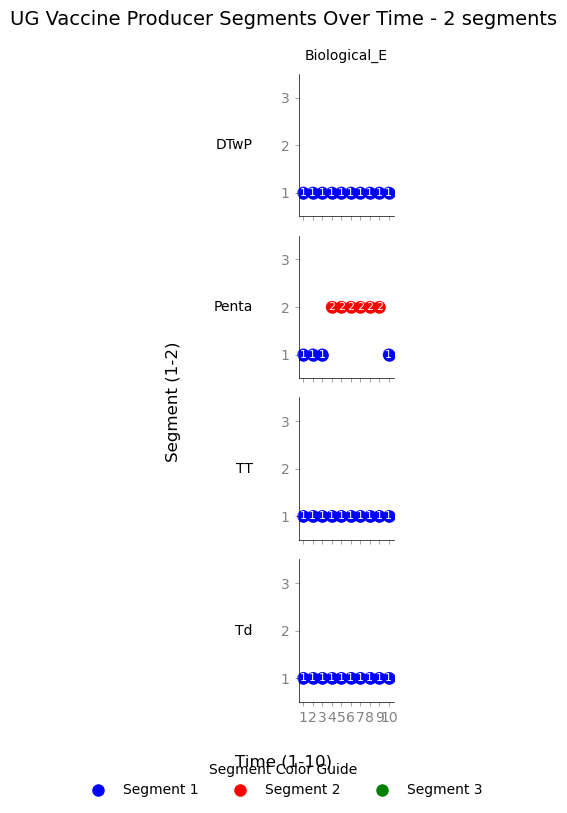

The Tufte-style graphic for trial 1 has been generated and saved as 'SINGLE_UG_2_segments_updated_0%_cap_inc_0%_supply_inc_vaccine_producer_segments_tufte_trial_1.png'.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import json # Import the json module to load JSON files


for trial in range(1, 2): 
    # Load the JSON file
    # filename = f"results/DE_demand_increase_sensitivity/MP Model/10 trial inc demand 3 segments no ROI/MVP_DE_results_T_10_delta_5_scen_1_trial_{trial}_inv_1_cap._1_cap.inc._1.json"
    # filename = f"results/segment tests/4 segments/MVP_DE_results_T_5_delta_5_scen_1_trial_{trial}_inv_1_cap._1_cap.inc._1.json"
    filename = f"results/3 segments controlled random seed/UG/MVP_DE_results_T_10_delta_5_scen_1_trial_{trial}_inv_1_cap._1_cap.inc._1.json"
    print(f"Processing file: {filename}") # Added for debugging

    try:
        with open(filename) as json_file:
            data = json.load(json_file)
    except FileNotFoundError:
        print(f"Error: File not found at {filename}. Skipping this trial.")
        continue # Skip to the next iteration if the file doesn't exist

    # Call the function to extract information
    result = extract_segments_with_z_value_1(data)

    # Transform the dictionary into a list of dictionaries for DataFrame creation
    flat_data = []
    for vaccine, producers_data in result.items():
        clean_vaccine_name = vaccine.replace(" vaccine", "").strip()
        for producer, segments_list in producers_data.items():
            for entry in segments_list:
                flat_data.append({
                    "Vaccine": clean_vaccine_name,
                    "Producer": producer,
                    "Time": entry['Time'],
                    "Segment": entry['Segment']
                })

    df = pd.DataFrame(flat_data)

    selected_producer = "Biological_E"  # <--- change this as needed
    df = df[df['Producer'] == selected_producer]

    if df.empty:
        print(f"No data found for producer '{selected_producer}'. Skipping.")
        continue

    # Only keep vaccines that producer makes
    unique_vaccines = sorted(df['Vaccine'].unique())
    unique_producers = [selected_producer]

    # Get unique vaccines and producers for faceting
    # Sort for consistent plot order
    unique_vaccines = sorted(df['Vaccine'].unique())
    unique_producers = sorted(df['Producer'].unique())

    # Determine grid size for subplots
    num_rows = len(unique_vaccines)
    num_cols = len(unique_producers)

    # Create the figure and subplots for the current trial
    # Clear the current figure to ensure a fresh plot for each trial
    plt.close('all') # Close all existing figures to prevent overlap
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2.5, num_rows * 2),
                             sharex='col', sharey='row', squeeze=False)

    # Define a color map for segments
    segment_colors = {
        1: 'blue',
        2: 'red',
        3: 'green'#,
        # 4: 'black'
    }

    # Iterate through each subplot to plot data
    for i, vaccine in enumerate(unique_vaccines):
        for j, producer in enumerate(unique_producers):
            ax = axes[i, j]
            subset_df = df[(df['Vaccine'] == vaccine) & (df['Producer'] == producer)]

            # Plot points and add segment labels
            for _, row in subset_df.iterrows():
                segment = row['Segment']
                color = segment_colors.get(segment, 'grey')
                ax.plot(row['Time'], row['Segment'], 'o', color=color, markersize=8, zorder=2)
                ax.text(row['Time'], row['Segment'], str(segment),
                        fontsize=8, ha='center', va='center', color='white',
                        bbox=dict(boxstyle="circle,pad=0.1", fc=color, ec="none", lw=0, alpha=0.8))

            # Set minimalist axes (Tufte style)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(0.5)
            ax.spines['bottom'].set_linewidth(0.5)

            # Remove ticks that don't align with segments/time
            ax.tick_params(axis='both', which='both', length=0)

            # Set x-axis ticks to be just the data points (1-10)
            ax.set_xticks(range(1, 11))
            ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
            ax.tick_params(axis='x', direction='out', length=3, width=0.5, colors='gray')

            # Set y-axis ticks to be just the segments (1, 2, 3)
            ax.set_yticks([1, 2, 3])
            ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
            ax.tick_params(axis='y', direction='out', length=3, width=0.5, colors='gray')

            ax.set_ylim(0.5, 3.5)
            ax.set_xlim(0.5, 10.5)

            # Set titles for individual subplots
            if i == 0:
                ax.set_title(producer, fontsize=10, pad=10)
            if j == 0:
                ax.set_ylabel(vaccine, fontsize=10, rotation=0, ha='right', va='center', labelpad=20)

    # Adjust layout and add overall titles for the current trial's plot
    fig.supxlabel('Time (1-10)', fontsize=12, y=0.04)
    fig.supylabel('Segment (1-2)', fontsize=12, x=0.03)

    plt.tight_layout(rect=[0.04, 0.04, 1, 0.96])
    plt.suptitle(f'UG Vaccine Producer Segments Over Time - 2 segments', fontsize=14, y=0.99) #Trial: {trial}

    # Create a custom legend for segment colors below the main chart
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=f'Segment {s}',
                                  markerfacecolor=c, markersize=10)
                       for s, c in segment_colors.items()]
    fig.legend(handles=legend_elements, loc='lower center', ncol=len(segment_colors),
               title='Segment Color Guide', bbox_to_anchor=(0.5, -0.01),
               fancybox=False, shadow=False, frameon=False)

    # Save the chart with a unique filename for each trial
    output_filename = f'SINGLE_UG_2_segments_updated_0%_cap_inc_0%_supply_inc_vaccine_producer_segments_tufte_trial_{trial}.png'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show() # Display the plot for the current trial

    print(f"The Tufte-style graphic for trial {trial} has been generated and saved as '{output_filename}'.")

Processing file: results/3 segments controlled random seed/UG/MVP_DE_results_T_10_delta_5_scen_1_trial_1_inv_1_cap._1_cap.inc._1.json


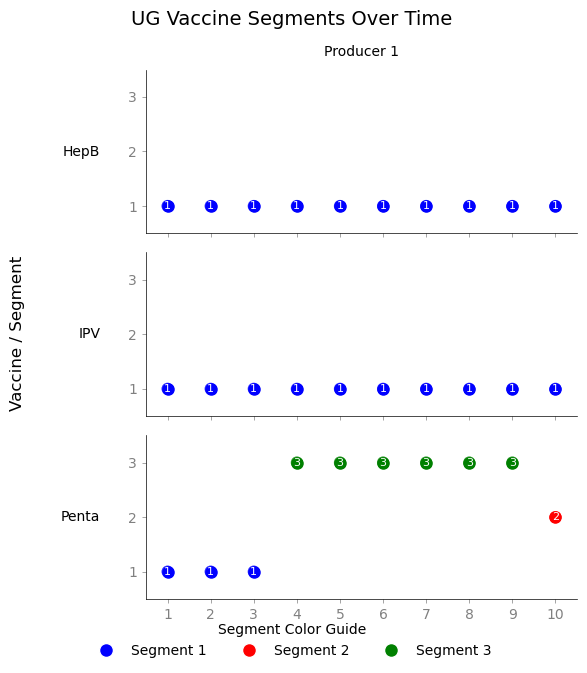

The Tufte-style graphic for masked producers (trial 1) has been saved as Producer 1_UG_2_segments_trial_1_1_Prod.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import json

for trial in range(1, 2):
    filename = f"results/3 segments controlled random seed/UG/MVP_DE_results_T_10_delta_5_scen_1_trial_{trial}_inv_1_cap._1_cap.inc._1.json"
    print(f"Processing file: {filename}")

    try:
        with open(filename) as json_file:
            data = json.load(json_file)
    except FileNotFoundError:
        print(f"Error: File not found at {filename}. Skipping this trial.")
        continue

    result = extract_segments_with_z_value_1(data)

    # --- Flatten data ---
    flat_data = []
    for vaccine, producers_data in result.items():
        clean_vaccine_name = vaccine.replace(" vaccine", "").strip()
        for producer, segments_list in producers_data.items():
            for entry in segments_list:
                flat_data.append({
                    "Vaccine": clean_vaccine_name,
                    "Producer": producer,
                    "Time": entry["Time"],
                    "Segment": entry["Segment"]
                })

    df = pd.DataFrame(flat_data)

    # --- Filter for multiple producers ---
    selected_producers = ["LG_Chem"]  # <--- choose producers here
    # df = df[df["Producer"].isin(selected_producers)]
    df = df[df["Producer"].isin(selected_producers)] #& ~df["Vaccine"].isin(["DT", "PCV", "Rotavirus", "DTwP-Hib", "IPV", "TT", "Td"])]


    if df.empty:
        print(f"No data found for producers {selected_producers}. Skipping.")
        continue

    # --- Mask producer names ---
    producer_mapping = {p: f"Producer {i+1}" for i, p in enumerate(sorted(selected_producers))}
    df["Producer_Masked"] = df["Producer"].map(producer_mapping)

    # --- Determine vaccines and grid ---
    unique_vaccines = sorted(df["Vaccine"].unique())
    unique_producers_masked = sorted(df["Producer_Masked"].unique())

    num_rows = len(unique_vaccines)
    num_cols = len(unique_producers_masked)

    # --- Dynamic figure sizing ---
    max_time = df["Time"].max() if not df.empty else 10
    fig_width = max(6, num_cols * max_time * 0.3)
    fig_height = num_rows * 2.2

    plt.close("all")
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(fig_width, fig_height),
                             sharex="col", sharey="row", squeeze=False)

    segment_colors = {1: "blue", 2: "red", 3: "green"}

    # --- Plot data ---
    for i, vaccine in enumerate(unique_vaccines):
        for j, producer_masked in enumerate(unique_producers_masked):
            ax = axes[i, j]

            # Find the actual producer name for this masked one
            actual_producer = {v: k for k, v in producer_mapping.items()}[producer_masked]
            subset_df = df[(df["Vaccine"] == vaccine) & (df["Producer"] == actual_producer)]

            for _, row in subset_df.iterrows():
                segment = row["Segment"]
                color = segment_colors.get(segment, "grey")
                ax.plot(row["Time"], row["Segment"], "o", color=color, markersize=8, zorder=2)
                ax.text(row["Time"], row["Segment"], str(segment),
                        fontsize=8, ha="center", va="center", color="white",
                        bbox=dict(boxstyle="circle,pad=0.1", fc=color, ec="none", lw=0, alpha=0.8))

            # --- Minimalist axes ---
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_linewidth(0.5)
            ax.spines["bottom"].set_linewidth(0.5)
            ax.tick_params(axis="both", which="both", length=0)

            ax.set_xticks(range(1, int(max_time) + 1))
            ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))
            ax.tick_params(axis="x", direction="out", length=3, width=0.5, colors="gray")

            ax.set_yticks(sorted(df["Segment"].unique()))
            ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%d"))
            ax.tick_params(axis="y", direction="out", length=3, width=0.5, colors="gray")

            ax.set_ylim(0.5, max(df["Segment"]) + 0.5)
            ax.set_xlim(0.5, max_time + 0.5)

            if i == 0:
                ax.set_title(producer_masked, fontsize=10, pad=10)
            if j == 0:
                ax.set_ylabel(vaccine, fontsize=10, rotation=0, ha="right", va="center", labelpad=20)

    # --- Layout and titles ---
    # fig.supxlabel("Time (1-10)", fontsize=12, y=0.04)
    fig.supylabel("Vaccine / Segment", fontsize=12, x=0.03)
    plt.tight_layout(rect=[0.04, 0.04, 1, 0.96])

    plt.suptitle("UG Vaccine Segments Over Time", fontsize=14, y=0.99)

    # --- Legend ---
    legend_elements = [plt.Line2D([0], [0], marker="o", color="w", label=f"Segment {s}",
                                  markerfacecolor=c, markersize=10)
                       for s, c in segment_colors.items()]
    fig.legend(handles=legend_elements, loc="lower center", ncol=len(segment_colors),
               title="Segment Color Guide", bbox_to_anchor=(0.5, -0.01),
               fancybox=False, shadow=False, frameon=False)

    # --- Save and show ---
    producers_str = "_".join([producer_mapping[p] for p in selected_producers])
    output_filename = f"{producers_str}_UG_2_segments_trial_{trial}_1_Prod"
    for ext in ("png", "jpg"):
        plt.savefig(f"{output_filename}.{ext}", dpi=300, bbox_inches="tight")

    plt.show()
    print(f"The Tufte-style graphic for masked producers (trial {trial}) has been saved as {output_filename}.")


In [10]:
filename = f"results/test new mccormick/mccormick/MVP_DE_results_T_10_delta_5_scen_1_trial_{trial}_inv_1_cap._1_cap.inc._1.json"
print(f"Processing file: {filename}") # Added for debugging

try:
    with open(filename) as json_file:
        data = json.load(json_file)
except FileNotFoundError:
    print(f"Error: File not found at {filename}. Skipping this trial.")

Processing file: results/test new mccormick/mccormick/MVP_DE_results_T_10_delta_5_scen_1_trial_1_inv_1_cap._1_cap.inc._1.json
Error: File not found at results/test new mccormick/mccormick/MVP_DE_results_T_10_delta_5_scen_1_trial_1_inv_1_cap._1_cap.inc._1.json. Skipping this trial.


In [23]:
import pandas as pd

rows = []

for (vaccine, producer_dict) in data['Q'].items():
    for (producer, t_dict) in producer_dict.items():
        for (t, tau_dict) in t_dict.items():
            for (tau, segment_dict) in tau_dict.items():
                for (segment, value) in segment_dict.items():
                    rows.append((vaccine, producer, t, tau, int(segment), value))

df = pd.DataFrame(rows, columns=["Vaccine", "Producer", "Start Year", "End Year", "Segment", "Value"])


# Model comparison

In [4]:
import pandas as pd, json, glob, re, os

def extract_and_compare(top_key, folder='.', export_excel=True):
    pattern = re.compile(r'MVP_DE_results_T_10_delta_5_scen_1_trial_(\d+)_inv_1_cap\._1_cap\.inc\._1\.json$')
    files = sorted(f for f in glob.glob(f'{folder}/*.json') if pattern.search(f))
    all_data = []
    for f in files:
        with open(f) as fh: data = json.load(fh)
        trial = f"trial_{pattern.search(os.path.basename(f)).group(1)}"
        rows = []
        def rec(d,p=()):
            if isinstance(d,dict): [rec(v,p+(k,)) for k,v in d.items()]
            else: rows.append((*p,d))
        rec(data[top_key])
        all_data.append(pd.DataFrame(rows, columns=[f'level_{i+1}' for i in range(len(rows[0])-1)]+[trial]))
    df = all_data[0]
    for other in all_data[1:]:
        df = pd.merge(df, other, on=[c for c in df.columns if c.startswith('level_')], how='outer')
    if export_excel:
        out = os.path.join(folder, f'{top_key}_comparison.xlsx')
        df.to_excel(out, index=False)
        print(f'✅ Exported to: {out}')
    return df

# Example usage:
df = extract_and_compare('S', folder="results/3 segments/MP")


✅ Exported to: results/3 segments/MP\S_comparison.xlsx


In [13]:
df

,level_1,level_2,level_3,trial_1,trial_2,trial_3,trial_4,trial_5
0,Diphtheria,0,1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,Diphtheria,1,1,3.146393e+07,3.146393e+07,3.146393e+07,3.146393e+07,3.146393e+07
2,Diphtheria,10,1,3.793046e+09,3.793046e+09,3.793046e+09,3.793046e+09,3.793046e+09
3,Diphtheria,2,1,4.952548e+08,4.952548e+08,4.952548e+08,4.952548e+08,4.952548e+08
4,Diphtheria,3,1,7.829150e+08,7.829150e+08,7.829150e+08,7.829150e+08,7.829150e+08
...,...,...,...,...,...,...,...,...
94,Tetanus,5,1,2.036664e+09,2.036664e+09,2.036664e+09,2.036664e+09,2.036664e+09
95,Tetanus,6,1,2.652231e+09,2.652231e+09,2.652231e+09,2.652231e+09,2.652231e+09
96,Tetanus,7,1,2.864928e+09,2.864928e+09,2.864928e+09,2.864928e+09,2.864928e+09
97,Tetanus,8,1,3.083592e+09,3.083592e+09,3.083592e+09,3.083592e+09,3.083592e+09
